# Demonstration of the Naïve Bayes Classifier with K-Fold Cross-Validation using cross_val_score() from sklearn.

Here’s a ready-to-run Python code that covers:

Loading dataset

Applying Naïve Bayes Classification

Validating using cross_val_score() with K-Fold

Using GaussianNB (for numeric features only)

# Why Use cross_val_score() and K-Fold?

cross_val_score() evaluates the model using K-Fold Cross-Validation.

K-Fold CV splits the dataset into K parts (folds):

Trains the model on K-1 parts

Tests on the remaining part

Repeats for all folds

Benefits:

Gives a more robust estimate of model performance.

Reduces the risk of overfitting to a single train-test split.

In [10]:
# ====================================
# IMPORTS
# ====================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Optional: Display all columns
pd.set_option('display.max_columns', None)

# Use consistent CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

=== Naïve Bayes on Iris Dataset ===

Cross-Validation Accuracy Scores: [0.96666667 0.96666667 0.9        1.         0.9       ]
Mean Accuracy: 0.9467


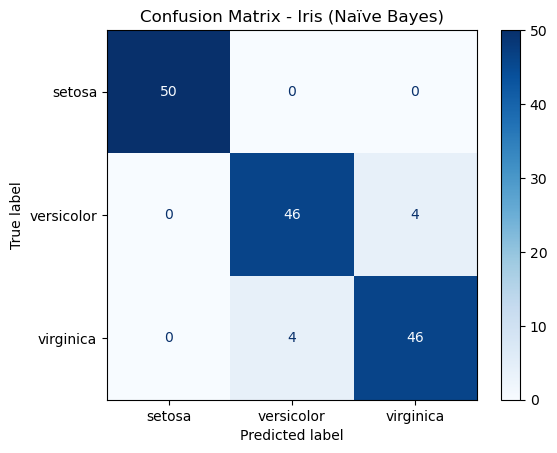

In [11]:
print("=== Naïve Bayes on Iris Dataset ===")

# Load dataset
iris = sns.load_dataset('iris')

# Features and target
X_iris = iris.drop(columns=['species'])
y_iris = iris['species']

# Pipeline: Standardize + Naive Bayes
iris_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# Cross-validation scores (accuracy)
iris_scores = cross_val_score(iris_pipeline, X_iris, y_iris, cv=cv, scoring='accuracy')
print(f"\nCross-Validation Accuracy Scores: {iris_scores}")
print(f"Mean Accuracy: {iris_scores.mean():.4f}")

# Predict all using cross_val_predict for confusion matrix
y_pred_iris = cross_val_predict(iris_pipeline, X_iris, y_iris, cv=cv)

# Confusion matrix
cm_iris = confusion_matrix(y_iris, y_pred_iris, labels=iris['species'].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm_iris, display_labels=iris['species'].unique())
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Iris (Naïve Bayes)")
plt.show()

What Are iris_scores?

These are lists of accuracy scores from each fold of cross-validation:
iris_scores = [accuracy on fold 1, fold 2, ..., fold 5]

The mean of these scores gives a better estimate of the classifier's generalisation performance.


=== Naïve Bayes on Diamonds Dataset ===

Cross-Validation Accuracy Scores: [0.16833333 0.14833333 0.19833333 0.17       0.125     ]
Mean Accuracy: 0.1620


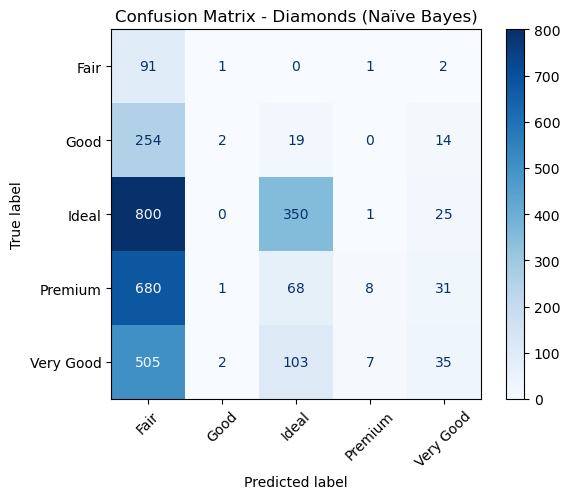

In [12]:
print("\n=== Naïve Bayes on Diamonds Dataset ===")

# Load dataset
diamonds = pd.read_csv("C:\\Users\\Somdip.Dey\\Desktop\\Regents_SWE6204\\diamonds.csv")
diamonds.columns = diamonds.columns.str.lower().str.strip()

# Target: 'cut', Features: others
X_diamond = diamonds.drop(columns=['cut'])
y_diamond = diamonds['cut']

# Identify features
cat_features = ['color', 'clarity']
num_features = [col for col in X_diamond.columns if col not in cat_features]

# Preprocessor: OneHot + Scaling
diamond_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_features),
    ('num', StandardScaler(), num_features)
])

# Pipeline
diamond_pipeline = Pipeline([
    ('preprocessor', diamond_preprocessor),
    ('nb', GaussianNB())
])

# Sample for faster processing
X_diamond_small = X_diamond.sample(3000, random_state=42)
y_diamond_small = y_diamond.loc[X_diamond_small.index]

# Cross-validation scores (accuracy)
diamond_scores = cross_val_score(diamond_pipeline, X_diamond_small, y_diamond_small, cv=cv, scoring='accuracy')
print(f"\nCross-Validation Accuracy Scores: {diamond_scores}")
print(f"Mean Accuracy: {diamond_scores.mean():.4f}")

# Predict for confusion matrix
y_pred_diamond = cross_val_predict(diamond_pipeline, X_diamond_small, y_diamond_small, cv=cv)

# Confusion matrix
labels_diamond = sorted(y_diamond_small.unique())
cm_diamond = confusion_matrix(y_diamond_small, y_pred_diamond, labels=labels_diamond)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_diamond, display_labels=labels_diamond)
disp2.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Diamonds (Naïve Bayes)")
plt.show()

What Are diamond_scores?

These are lists of accuracy scores from each fold of cross-validation:
diamond_scores = [accuracy on fold 1, fold 2, ..., fold 5]

The mean of these scores gives a better estimate of the classifier's generalisation performance.

# What Does the Confusion Matrix Show?

A confusion matrix shows how many examples of each actual class were predicted as each predicted class.

Diagonal = correct predictions

Off-diagonal = misclassifications

This helps identify:

Which classes are being confused

Where misclassification is highest